<a href="https://colab.research.google.com/github/riteshkrkumarweb/Learning_AI/blob/main/MSE%2C_MAE_%26_RMSE_%7C_R2_Score_%26_Adjusted_R2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
parvmodi_cgpa_vs_package_in_lpa_path = kagglehub.dataset_download('parvmodi/cgpa-vs-package-in-lpa')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**What is MSE ?**
💡 Meaning:Difference between actual value (y) and predicted value (ŷ)
Squared error → bigger mistakes get heavily punished

**👍 Advantages:**
Penalizes large errors strongly (good for sensitive systems)
Smooth & differentiable → useful for training model

**👎 Disadvantages:**
Sensitive to outliers

Units are squared → not easy to interpret
MSE confusing hai kyunki **answer** real world unit me nahi hota
jaise Original unit = ₹ (rupees)
After MSE = ₹² (rupees squared)👉 Real life me ₹² ka koi meaning nahi hota

MAE & RMSE easy hai kyunki same unit me hote hain
        

**what is MAE** ?:-> (Mean Absolute Error)

**💡Meaning:**
Average of absolute differences
Absolute = remove the sign (ignore + or -)
👉 Only care about how big the difference is

**👍Advantages:**
Easy to understand
Not heavily affected by outliers

**👎 Disadvantages:**
Doesn’t punish large errors enough
Not smooth (less ideal for optimization

Not smooth means A graph that has a sharp corner / point
Smooth means A graph that is curved nicely (no sharp edges)

**What is RMSE ?**
            📊 3. RMSE (Root Mean Squared Error)

**💡 Meaning:**
Square root of MSE → back to original units

**👍 Advantages:**
Easy interpretation (same unit as data) Matlab agar output Lakh me hau to output bhi lakh me aayega
Still penalizes large errors

**👎 Disadvantages:**
Sensitive to outliers (like MSE)

**what is R² Score ?** R² Score (Coefficient of Determination)

**Meaning**:
How well model explains the data
Range:
1 → perfect
0 → useless
negative → very bad

👉 Suppose:
Tumhe CGPA se package predict karna hai
But tumhare paas CGPA data nahi hai

🔴 Case 1: No model (baseline)
👉 Tum kya karoge?
Sab logon ke package dekhoge
Unka average (mean) nikal loge
Har kisi ko wahi predict kar doge
👉 Ye default / dumb prediction hai

🟢 Case 2: Model use karte ho
👉 Ab tum:
CGPA use karte ho
Better prediction karte ho
💡 R² kya bolta hai?
Tumhara model average se kitna better hai

📊 Simple Interpretation
R² = 0
👉 Model = average jaisa hi
👉 Koi improvement nahi
R² = 1
👉 Perfect prediction 😎
👉 Sab exact match
R² = 0.6 (example)
👉 Model average se 60% better
R² < 0 (negative)
👉 😵 Model average se bhi worse

👉 **Matlab**:
“Average hi better tha, model bekaar hai”
R² = How much better your model is than just taking average

👍 **Advantages**:
Easy to compare models
Scale independent

👎 **Disadvantages**:
Can increase even with useless features
Misleading sometimes

See Image - https://ashutoshtripathi.com/wp-content/uploads/2019/01/rsquarecanva2.png

** what is Adjusted R² Score ?**

💡 **Meaning**:
Penalizes adding unnecessary features

👍 **Advantages**:
Prevents overfitting
Better than R² for multiple features

👎 **Disadvantages**:
Slightly harder to understand

See the image - https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/10_adjusted-r-squared.jpeg

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/parvmodi/cgpa-vs-package-in-lpa/placement.csv')

In [ ]:
df

In [ ]:
df.head(16)

In [ ]:
df.isnull().sum() #Checking that if any data is not null

In [ ]:
import matplotlib.pyplot as plt  # EDA using the scatter Plot

plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('LPA(in lakh)')
plt.title('package Graph')

In [ ]:
# This is Correct But in scikit-learn, it is usually better to keep X as 2D
X = iloc[:,0] #This is 1D so write like  X = iloc[:,0:1]
y = iloc[:,-1] # Output Column is enough if it is 1D
# df.iloc[:, 0] gives a Series shape like (199,)
df.iloc[:, [0]]# gives a DataFrame shape like (199, 1)-> 2D
''' how double bracket is 2D ?
    [6.89, 5.12, 7.82, 7.42] Only one direction ->1D

    [[6.89],
     [5.12],
     [7.82],
     [7.42]] -> 2D Rows and columns:
'''
X = df.iloc[:, 0:1] # → 2D


#Ignore the errors



In [ ]:
X = df.iloc[:,0:1]# All row and 0 column ✅
y = df.iloc[:,-1]# All row and from last one column

In [ ]:
X

In [ ]:
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#20% data will go to test set and the remaining 80% data will go to train set
#42 has no special magic here. It can be 0, 1, 10, 99 too. It is just a fixed number. 42 is used a lot by people as a common example.

In [ ]:
X_train # This is Training set

In [ ]:
y_train #Training set output column

In [ ]:
from sklearn.linear_model import LinearRegression #Import the model
model = LinearRegression()

In [ ]:
model.fit(X_train , y_train) # Train the model fit means Train

In [ ]:
X_test

In [ ]:
y_test

In [ ]:
# This causes the warning
model.predict(X_test.iloc[2].values.reshape(1,1))
# X_test.iloc[2] -> pandas Series with name 'cgpa'
# .values -> numpy array without feature name

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.1995207])

In [ ]:
'''Here we doing first we take the 1 index of the X_test and
and predict the result then which is array([2.78031348]) like this
then we match the y_test which is our actual value.'''

model.predict(X_test.iloc[[4]]) # Use double brackets to keep it as DataFrame ✅





array([3.52684689])

Text(0.5, 1.0, 'package Graph')

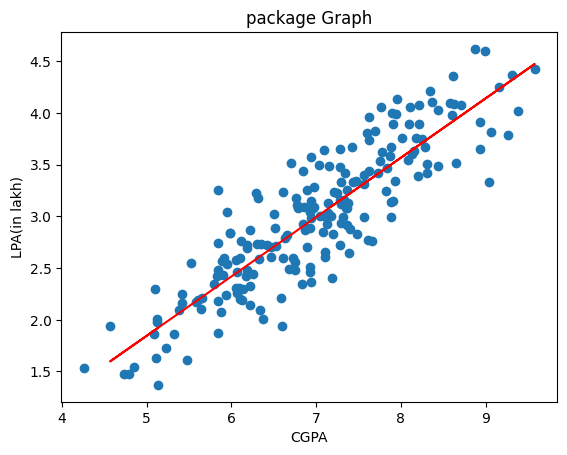

In [ ]:
plt.scatter(df['cgpa'],df['package'])# Plots all data points
#plt.plot(X_test,model.predict(X_test),color='red') #This is the Linear Line
# The Linear Regression has predict on all the X_train data Points

plt.plot(X_train,model.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('LPA(in lakh)')
plt.title('package Graph')

In [ ]:
#In y = mx+b This is the m
#m decides tilt of line
m = model.coef_

In [ ]:
'''Why it is negetive
Because the best-fit line is chosen mathematically
Sometimes to stay close to all points, the line must shift downward a bit.
That makes b negative.
-1.027 means the regression line crosses the y-axis at -1.027, because that gives the best fit to your data.'''
#In y = mx+b This is the
#b decides where line starts on y-axis
b = model.intercept_
print(b)


-1.0270069374542108


In [ ]:
#Make Prediction
y_predict = model.predict(X_test)

In [ ]:
'''accuracy_score compares exact matches, which doesn't make sense for continuous values. For example:
Actual: 5.2 LPA, Predicted: 5.3 LPA
This would be counted as "incorrect" even though it's very close!'''
#from sklearn.metrics import accuracy_score
#accuracy = accuracy_score(y_test, y_predict) # ❌ Wrong for regression!
# I have done Wrong Not U Write that Learn form Mistakes

'accuracy_score compares exact matches, which doesn\'t make sense for continuous values. For example:\nActual: 5.2 LPA, Predicted: 5.3 LPA\nThis would be counted as "incorrect" even though it\'s very close!'

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
y_predict = model.predict(X_test)
y_predict

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [ ]:
y_test.values

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [ ]:
print('MAE',mean_absolute_error(y_test,y_predict))
'''
The more close the to 0 when we subract the y(real value)-yhat(predicted value)
here the model is doing on an average 23 '''

MAE 0.23150985393278373


In [ ]:
'''
R² < 0.3  → Weak model (explains very little variance)
R² 0.3-0.5 → Moderate model (decent but room for improvement)
R² 0.5-0.7 → Strong model (good predictive power)
R² > 0.7  → Very strong model (excellent fit, but check for overfitting)
'''